# Interplay: t-SNE of the final-position TV — normal vs amplified pairing

Visualize the final-position representation at a chosen layer under normal vs amplified
pairing heads, embedded with **t-SNE** (2D), colored by task.

⚠️ t-SNE preserves *local neighborhoods*, not global distances. Use it to **eyeball
clustering**, NOT to judge how far amplified points moved. The trustworthy quantitative
test is the within-task-spread number (computed below in full vector space).

Reuses repo machinery. Put in `experiments/interplay/`.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

import experiments.pairing._common as C
from data.loaders import load_dataset
from utils.heads import get_head_sets_multiscope, select_scope, make_amplify_hooks
sns.set_context('notebook')

## Config

In [2]:
DATASET   = 'hendel'
HEAD_PCT  = 10
SCOPE     = 'pooled'
SCALES    = [1.0, 3.0]
N_PROMPTS = 20
LAYER     = 13               # layer to embed (try a few; ~TV-formation layers)
NORMALIZE = True             # L2-normalize before embedding (direction, not magnitude)
PERPLEXITY= 30
CUDA      = '0'
ds_tag = DATASET.replace('+','_')

model = C.load_model(cuda_visible=CUDA)
n_layers = model.cfg.n_layers
splits = load_dataset(DATASET)
tasks = sorted(splits.keys())
print(f'{DATASET}: {len(tasks)} tasks, layer={LAYER}, scales={SCALES}')

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
hendel: 20 tasks, layer=13, scales=[1.0, 3.0]


## Head sets

In [3]:
cache = f'../../results/head_sets_{ds_tag}_pct{HEAD_PCT}.pkl'
if os.path.exists(cache):
    with open(cache,'rb') as f: ms = pickle.load(f); print('loaded cached head sets')
else:
    ms = get_head_sets_multiscope(model, splits, pct=HEAD_PCT, n_prompts=N_PROMPTS,
                                  cache_path=cache, verbose=True)
pairing = select_scope(ms, SCOPE)['pairing']
print(f'{len(pairing)} pairing heads')

loaded cached head sets
67 pairing heads


## Extract final-position residual at LAYER, normal vs amplified

In [4]:
@torch.no_grad()
def final_resid(prompt, arrow_pos, layer, hooks=None):
    toks = model.to_tokens(prompt, prepend_bos=True)
    rf = lambda n: n == f'blocks.{layer}.hook_resid_post'
    if hooks:
        with model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(toks, names_filter=rf)
    else:
        _, cache = model.run_with_cache(toks, names_filter=rf)
    v = cache[f'blocks.{layer}.hook_resid_post'][0, arrow_pos].float().cpu().numpy()
    del cache; torch.cuda.empty_cache(); return v

hook_for = {s: (None if s==1.0 else make_amplify_hooks(pairing, s)) for s in SCALES}
jobs = [(t,i,pd_) for t in tasks for i,pd_ in enumerate(splits[t]['icl_prompts'][:N_PROMPTS])]
rows, vecs = [], []
for t,i,pd_ in tqdm(jobs):
    arrow = C.query_arrow_position(model, pd_['prompt'])
    for s in SCALES:
        rows.append({'task':t,'prompt_idx':i,'scale':s}); vecs.append(final_resid(pd_['prompt'],arrow,LAYER,hook_for[s]))
vecs=np.stack(vecs); meta=pd.DataFrame(rows)
print('extracted', vecs.shape)

  0%|          | 0/400 [00:00<?, ?it/s]

extracted (800, 3072)


## t-SNE (fit on normal + amplified TOGETHER so they share an embedding)
Colored by task; marker distinguishes scale (o = normal, x = amplified).

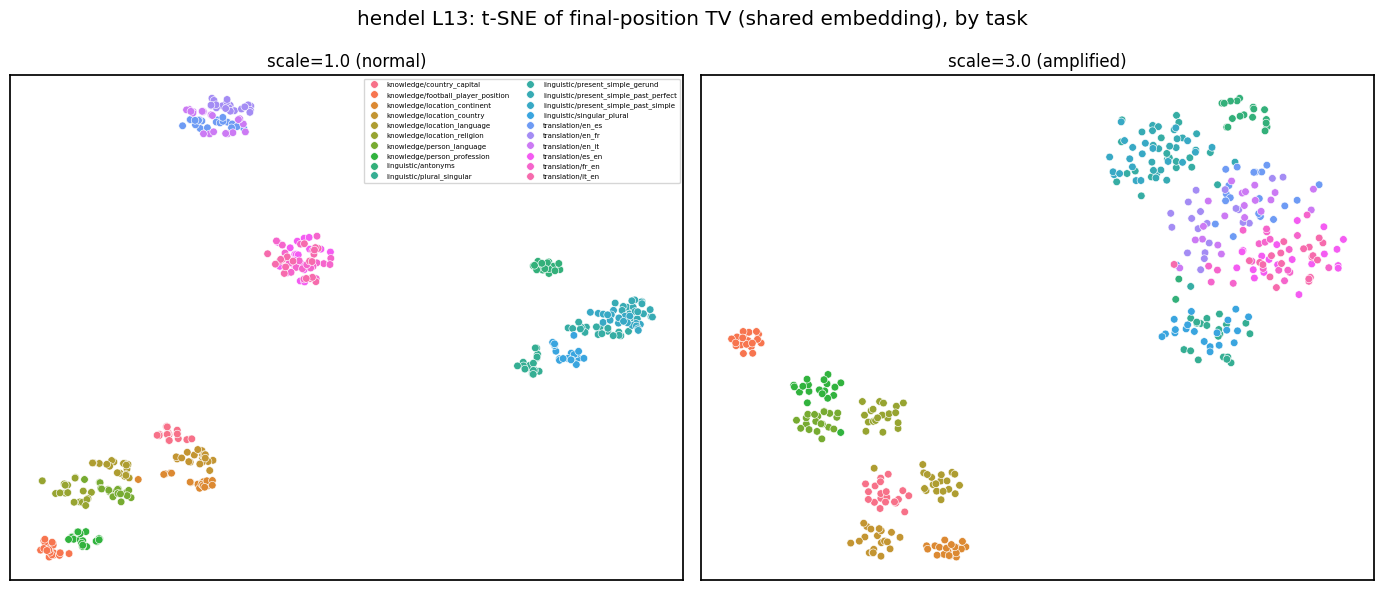

In [5]:
X = vecs/(np.linalg.norm(vecs,axis=1,keepdims=True)+1e-8) if NORMALIZE else vecs
emb = TSNE(n_components=2, perplexity=PERPLEXITY, init='pca', random_state=0).fit_transform(X)
meta['t1']=emb[:,0]; meta['t2']=emb[:,1]

# side-by-side: one panel per scale, colored by task
fig, axes = plt.subplots(1, len(SCALES), figsize=(7*len(SCALES),6), squeeze=False)
for ax,s in zip(axes[0], SCALES):
    sub = meta[meta.scale==s]
    sns.scatterplot(sub, x='t1', y='t2', hue='task', s=30, ax=ax, legend=(s==SCALES[0]))
    ax.set(title=f'scale={s} ({"normal" if s==1.0 else "amplified"})', xlabel='', ylabel='')
    ax.set_xticks([]); ax.set_yticks([])
    if s==SCALES[0]: ax.legend(fontsize=5, ncol=2, loc='best')
fig.suptitle(f'{DATASET} L{LAYER}: t-SNE of final-position TV (shared embedding), by task')
fig.tight_layout(); fig.savefig(f'tsne_task_{ds_tag}_L{LAYER}.png', dpi=130, bbox_inches='tight'); plt.show()

## Overlay: both scales in one t-SNE, marker = scale

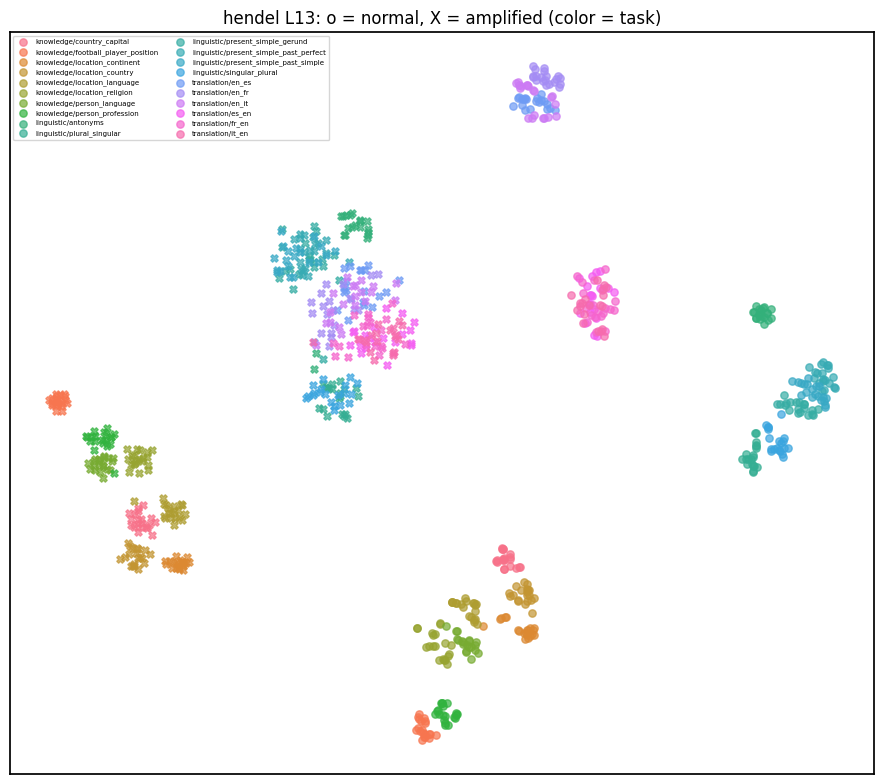

In [6]:
fig, ax = plt.subplots(figsize=(9,8))
tasks_u = sorted(meta.task.unique()); pal = dict(zip(tasks_u, sns.color_palette('husl', len(tasks_u))))
for s, mk in zip(SCALES, ['o','X']):
    sub = meta[meta.scale==s]
    for t in tasks_u:
        g = sub[sub.task==t]
        ax.scatter(g.t1, g.t2, color=pal[t], marker=mk, s=28, alpha=.7,
                   label=(t if s==SCALES[0] else None))
ax.set(title=f'{DATASET} L{LAYER}: o = normal, X = amplified (color = task)', xlabel='', ylabel='')
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=5, ncol=2, loc='best')
fig.tight_layout(); fig.savefig(f'tsne_overlay_{ds_tag}_L{LAYER}.png', dpi=130, bbox_inches='tight'); plt.show()

## Quantitative check (the trustworthy part — full vector space, not t-SNE)
Within-task spread = mean distance of same-task vectors to their task centroid.
Higher under amplification ⇒ more prompt-specific. This is the number to cite; the
t-SNE above is illustration only.

In [7]:
def spread(scale):
    idx = (meta.scale==scale).values; Xs = X[idx]; ts = meta.task[meta.scale==scale].values
    d=[]
    for t in np.unique(ts):
        pts=Xs[ts==t]; c=pts.mean(0); d.append(np.linalg.norm(pts-c,axis=1).mean())
    return np.mean(d)
for s in SCALES: print(f'within-task spread (L{LAYER}, normalize={NORMALIZE}) scale={s}: {spread(s):.4f}')

within-task spread (L13, normalize=True) scale=1.0: 0.4204
within-task spread (L13, normalize=True) scale=3.0: 0.4566


## Notes
- Read **clustering** from t-SNE, not distances. For "did amplification spread same-task
  points," trust the spread number, not the picture.
- Try a few `LAYER` values and `NORMALIZE=False` (magnitude); contrast `DATASET='nonce+arithmetic'`.